# Event Log - Estratégia b) - Molding

---

# Guiding Principles

- GP1: Event Data Should be Treated as First-Class Citizens
- GP2: Log Extraction Should Be Driven by Questions
- GP3: Concurrency, Choice and Other Basic Control-Flow Constructs Should be Supported
- GP4: Events Should Be Related to Model Elements
- GP5: Models Should Be Treated as Purposeful (intencional/significativo) Abstractions of Reality
- GP6: Process Mining Should Be a Continuous Process

---

# Configurações

> JupyterLab configurations

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

In [3]:
# import warnings
# warnings.filterwarnings("ignore")

In [4]:
import time, os, json, joblib

In [5]:
from pathlib import Path
from scipy import stats

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)
# Prevent line wrapping across the terminal/console screen
pd.set_option('display.width', None) 

In [8]:
import matplotlib.pyplot as plt

In [9]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

---

# Carregar b) de arquivo

In [10]:
%%time
lab_b = pd.read_parquet("Comiset23_Lab_Dataset/lab_b_eventlog.parquet")

CPU times: total: 7.27 s
Wall time: 5.66 s


In [11]:
lab_b.head(3)

,case_id,activity,timestamp,host_name,process_guid,process_name,process_path,process_id,process_parent_guid,process_parent_name,process_parent_id,event_id,source_name,_channel,rule_technique_id,rule_technique_name,is_malicious
0,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-6374-7001-000000002800,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
1,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-6374-7001-000000002800,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
2,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-6374-7001-000000002800,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False


In [12]:
print(f"Event log bruto: {len(lab_b):,} eventos | {lab_b.shape[1]} atributos | {lab_b['case_id'].nunique():,} casos")

Event log bruto: 3,504,996 eventos | 17 atributos | 2,516 casos


---

# Parâmetros do Pipeline

In [13]:
TIME_RESOLUTION = "1s"      # resolução temporal: "100ms", "1s", "10s", "30s", "1min"
PARETO_THRESHOLD = 0.80;    # cobertura mínima pra filtro de variantes (0.80 = top 80%)

---

# Arredondando `timestamp`

> Colocando a nova coluna ao lado da antiga, pra menos carga cognitiva

In [14]:
idx = lab_b.columns.get_loc("timestamp")

2

In [15]:
lab_b.insert(loc=idx + 1, column="ts_round", value=lab_b["timestamp"].dt.floor(TIME_RESOLUTION))

In [16]:
# quantos timestamps distintos existiam vs agora?
n_ts_before = lab_b["timestamp"].nunique()
n_ts_after = lab_b["ts_round"].nunique()
print(f"Timestamps distintos: {n_ts_before:,} -> {n_ts_after:,} (resolução {TIME_RESOLUTION}) | Redução de {(1 - n_ts_after / n_ts_before) * 100:.1f}%")

Timestamps distintos: 1,453,258 -> 46,700 (resolução 1s) | Redução de 96.8%


---

# Deduplicando a tripla `(case_id, activity, ts_round)`

In [17]:
n_before = len(lab_b)

lab_b_dedup = lab_b.drop_duplicates(
    subset=["case_id", "activity", "ts_round"]
).copy()

n_after = len(lab_b_dedup)
reduction = (n_before - n_after) / n_before

print(f"Deduplicação ({TIME_RESOLUTION}):")
print(f"  Antes:    {n_before:,}  eventos")
print(f"  Depois:   {n_after:,}    eventos")
print(f"  Redução:  {n_before - n_after:,}  ({reduction:.1%})")
print(f"  Casos:    {lab_b_dedup['case_id'].nunique():,}")

Deduplicação (1s):
  Antes:    3,504,996  eventos
  Depois:   227,533    eventos
  Redução:  3,277,463  (93.5%)
  Casos:    2,516


In [18]:
lab_b_dedup

,case_id,activity,timestamp,ts_round,host_name,process_guid,process_name,process_path,process_id,process_parent_guid,process_parent_name,process_parent_id,event_id,source_name,_channel,rule_technique_id,rule_technique_name,is_malicious
0,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-6374-7001-000000002800,RegistryAddDel,2022-11-16 08:23:14.392000+00:00,2022-11-16 08:23:14+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
152,desktop-4pvps6e.phoenix.local|4FD6B357-7918-636F-2900-000000002800,RegistryAddDel,2022-11-16 08:23:14.488000+00:00,2022-11-16 08:23:14+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-7918-636F-2900-000000002800,remotemouse.exe,c:\\program files (x86)\\remote mouse\\remotemouse.exe,2736,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
189,desktop-4pvps6e.phoenix.local|4FD6B357-9DE7-6374-8F01-000000002800,ImageLoaded,2022-11-16 08:23:14.963000+00:00,2022-11-16 08:23:14+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9DE7-6374-8F01-000000002800,dismhost.exe,c:\\windows\\temp\\961e6d2c-09d3-428b-a2a6-67bd522dbbeb\\dismhost.exe,6088,<NA>,<NA>,<NA>,7,Microsoft-Windows-Sysmon,sysmon,T1574.002,DLL Side-Loading,True
212,desktop-4pvps6e.phoenix.local|4FD6B357-7918-636F-2900-000000002800,RegistryAddDel,2022-11-16 08:23:15.055000+00:00,2022-11-16 08:23:15+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-7918-636F-2900-000000002800,remotemouse.exe,c:\\program files (x86)\\remote mouse\\remotemouse.exe,2736,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
215,desktop-4pvps6e.phoenix.local|4FD6B357-9D72-6374-7001-000000002800,RegistryAddDel,2022-11-16 08:23:15.083000+00:00,2022-11-16 08:23:15+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-9D72-6374-7001-000000002800,sysmon64.exe,c:\\windows\\sysmon64.exe,7420,<NA>,<NA>,<NA>,12,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3504987,desktop-4pvps6e.phoenix.local|4FD6B357-54B0-6375-9B01-000000002900,NetworkConnect,2022-11-16 23:53:57+00:00,2022-11-16 23:53:57+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-54B0-6375-9B01-000000002900,beacon.exe,c:\\users\\louis\\desktop\\tools\\beacon.exe,2784,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,T1036,Masquerading,True
3504991,desktop-4pvps6e.phoenix.local|4FD6B357-3669-6375-0B00-000000002900,NetworkConnect,2022-11-16 23:54:00.180000+00:00,2022-11-16 23:54:00+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504993,desktop-4pvps6e.phoenix.local|4FD6B357-3669-6375-0B00-000000002900,NetworkConnect,2022-11-16 23:55:04.055000+00:00,2022-11-16 23:55:04+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-3669-6375-0B00-000000002900,lsass.exe,c:\\windows\\system32\\lsass.exe,548,<NA>,<NA>,<NA>,3,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False
3504994,desktop-4pvps6e.phoenix.local|4FD6B357-DB03-6375-8602-000000002900,DNSEvent,2022-11-16 23:56:07.854000+00:00,2022-11-16 23:56:07+00:00,desktop-4pvps6e.phoenix.local,4FD6B357-DB03-6375-8602-000000002900,setuphost.exe,c:\\$windows.~bt\\sources\\setuphost.exe,3312,<NA>,<NA>,<NA>,22,Microsoft-Windows-Sysmon,sysmon,<NA>,<NA>,False


---

# Extraindo _Traces_ (Sequências de Atividades por Caso)

In [19]:
t0 = time.perf_counter()

traces = (
    lab_b_dedup
    .sort_values(["case_id", "ts_round"])
    .groupby("case_id")["activity"]
    .apply(tuple)
)

# contar variantes
variant_counts = traces.value_counts()
n_variants = len(variant_counts)
n_cases = len(traces)

print(f"Extração de traces: {time.perf_counter() - t0:.1f}s")
print(f"Total de casos: {n_cases:,}")
print(f"Variantes únicas: {n_variants:,}")
print(f"Razão: {n_cases / n_variants:.1f} casos por variante em média")

Extração de traces: 0.4s
Total de casos: 2,516
Variantes únicas: 673
Razão: 3.7 casos por variante em média


In [20]:
variant_counts.head()

activity
(ProcessCreate,)                                               964
(ProcessCreate, ImageLoaded)                                   141
(ProcessCreate, ImageLoaded, RegistryAddDel)                    60
(ProcessCreate, ImageLoaded, RegistryAddDel, PipeConnected)     47
(ImageLoaded,)                                                  46
Name: count, dtype: int64

In [21]:
print(f"Total de Variantes = {len(variant_counts)}")

Total de Variantes = 673


---

# Quais os rótulos MITRE dos _Traces_?

In [24]:
# === PERFIL POR CASO: cruzar com labels MITRE ===
case_profile = lab_b_dedup.groupby("case_id").agg(
    trace=("activity", lambda x: tuple(x)),
    trace_len=("activity", "size"),
    has_malicious=("is_malicious", "any"),
    n_mal_events=("is_malicious", "sum"),
    process_name=("process_name", "first"),
    techniques=("rule_technique_id", lambda x: set(x.dropna())),
).reset_index()

case_profile["trace_str"] = case_profile["trace"].apply(lambda t: " -> ".join(t))

print(f"Casos totais:      {len(case_profile):,}")
print(f"Casos maliciosos:  {case_profile['has_malicious'].sum():,}")
print(f"Casos benignos:    {(~case_profile['has_malicious']).sum():,}")

Casos totais:      2,516
Casos maliciosos:  1,225
Casos benignos:    1,291


In [34]:
# === VARIANTES: qual fração de seus casos contém malicioso? ===
variant_profile = case_profile.groupby("trace_str").agg(
    n_cases=("case_id", "size"),
    n_malicious=("has_malicious", "sum"),
    n_benign=("has_malicious", lambda x: (~x).sum()),
    example_process=("process_name", "first"),
    all_techniques=("techniques", lambda x: set.union(*x) if any(x) else set()),
    trace_len=("trace_len", "first"),
).reset_index()

variant_profile["pct_malicious"] = variant_profile["n_malicious"] / variant_profile["n_cases"]
variant_profile = variant_profile.sort_values("n_cases", ascending=False).reset_index(drop=True)

# classificar variantes
variant_profile["class"] = "benigna"
variant_profile.loc[
    (variant_profile["pct_malicious"] > 0) & (variant_profile["pct_malicious"] < 1),
    "class"
] = "mista"
variant_profile.loc[variant_profile["pct_malicious"] == 1, "class"] = "maliciosa"

print(f"Variantes por classe:")
class_summary = variant_profile.groupby("class").agg(
    n_variantes=("trace_str", "size"),
    n_casos=("n_cases", "sum"),
)
class_summary["pct_variantes"] = class_summary["n_variantes"] / class_summary["n_variantes"].sum()
class_summary["pct_casos"] = class_summary["n_casos"] / class_summary["n_casos"].sum()
class_summary

Variantes por classe:


,n_variantes,n_casos,pct_variantes,pct_casos
class,,,,
benigna,164,275,0.2437,0.1093
maliciosa,486,854,0.7221,0.3394
mista,23,1387,0.0342,0.5513


In [26]:
# === VARIANTES MALICIOSAS: quais são, quais técnicas, quais processos? ===
mal_variants = variant_profile[variant_profile["pct_malicious"] > 0].sort_values(
    "n_malicious", ascending=False
)

print(f"Variantes com pelo menos 1 caso malicioso: {len(mal_variants)}\n")
for _, row in mal_variants.head(20).iterrows():
    # trace legível: truncar se muito longo
    trace_display = row["trace_str"]
    if len(trace_display) > 90:
        trace_display = trace_display[:87] + "..."
    techs = ", ".join(sorted(row["all_techniques"])) if row["all_techniques"] else "-"
    print(
        f"  [{row['n_malicious']:>3}/{row['n_cases']:>3} mal]"
        f"  len={row['trace_len']:>3}"
        f"  {row['class']:10s}"
        f"  proc={row['example_process']}"
    )
    print(f"    trace: {trace_display}")
    print(f"    MITRE: {techs}")
    print()

Variantes com pelo menos 1 caso malicioso: 509

  [125/964 mal]  len=  1  mista       proc=gpupdate.exe
    trace: ProcessCreate
    MITRE: T1016, T1018, T1027, T1033, T1049, T1059, T1059.001, T1204, T1218, T1218.002, T1218.010, T1543.003, T1546.008

  [116/141 mal]  len=  2  mista       proc=schtasks.exe
    trace: ProcessCreate -> ImageLoaded
    MITRE: T1003.004, T1047, T1053, T1055, T1059.001, T1204, T1218.002

  [ 47/ 47 mal]  len=  4  maliciosa   proc=wmiprvse.exe
    trace: ProcessCreate -> ImageLoaded -> RegistryAddDel -> PipeConnected
    MITRE: T1003, T1047

  [ 45/ 45 mal]  len=  3  maliciosa   proc=mscorsvw.exe
    trace: ProcessCreate -> FileCreate -> FileDelete
    MITRE: T1574.010

  [ 40/ 40 mal]  len=  2  maliciosa   proc=sihclient.exe
    trace: ProcessCreate -> FileCreate
    MITRE: T1202, T1574.010

  [ 39/ 46 mal]  len=  1  mista       proc=installassistservice.exe
    trace: ImageLoaded
    MITRE: T1047, T1053, T1055, T1574.002

  [ 28/ 28 mal]  len=  3  maliciosa

In [27]:
# === SOMENTE MALICIOSOS: event log filtrado ===
lab_b_mal = lab_b_dedup[lab_b_dedup["is_malicious"]].copy()

print(f"Eventos maliciosos: {len(lab_b_mal):,}")
print(f"Casos envolvidos:   {lab_b_mal['case_id'].nunique():,}")
print(f"\nAtividades mais frequentes em eventos maliciosos:")
print(lab_b_mal["activity"].value_counts().to_string())
print(f"\nTécnicas MITRE mais frequentes:")
print(lab_b_mal["rule_technique_id"].value_counts().head(15).to_string())
print(f"\nProcessos mais frequentes em eventos maliciosos:")
print(lab_b_mal["process_name"].value_counts().head(15).to_string())

Eventos maliciosos: 17,060
Casos envolvidos:   1,225

Atividades mais frequentes em eventos maliciosos:
activity
NetworkConnect          9643
ProcessAccess           2358
FileCreate              1788
RegistryAddDel          1130
ImageLoaded              885
RegistryValueSet         818
ProcessCreate            336
CreateRemoteThread        98
FileCreateStreamHash       4

Técnicas MITRE mais frequentes:
rule_technique_id
T1036        9466
T1055.001    2283
T1574.010    1744
T1543        1388
T1055         309
T1053         271
T1574.002     250
T1059.001     244
T1047         229
T1553.004     209
T1003         144
T1204          97
T1021          86
T1003.002      56
T1547.001      35

Processos mais frequentes em eventos maliciosos:
process_name
beacon.exe                  9070
svchost.exe                 2635
explorer.exe                2215
wmiprvse.exe                 339
beacon2.exe                  312
mscorsvw.exe                 215
powershell.exe               202
lsass.exe  

In [28]:
# === TRACES DOS CASOS MALICIOSOS (só os que têm pelo menos 1 evento mal) ===
mal_case_ids = case_profile.loc[case_profile["has_malicious"], "case_id"]
traces_mal = traces[traces.index.isin(mal_case_ids)]
variant_counts_mal = traces_mal.value_counts()

print(f"Casos maliciosos: {len(traces_mal):,}")
print(f"Variantes (apenas entre casos maliciosos): {len(variant_counts_mal):,}")
print(f"\nTop 15 variantes entre casos maliciosos:")
for i, (trace, count) in enumerate(variant_counts_mal.head(15).items()):
    trace_str = " -> ".join(trace)
    if len(trace_str) > 90:
        trace_str = trace_str[:87] + "..."
    print(f"  {i+1:>3}. [{count:>3} casos, len={len(trace):>3}] {trace_str}")

Casos maliciosos: 1,225
Variantes (apenas entre casos maliciosos): 509

Top 15 variantes entre casos maliciosos:
    1. [125 casos, len=  1] ProcessCreate
    2. [116 casos, len=  2] ProcessCreate -> ImageLoaded
    3. [ 47 casos, len=  4] ProcessCreate -> ImageLoaded -> RegistryAddDel -> PipeConnected
    4. [ 45 casos, len=  3] ProcessCreate -> FileCreate -> FileDelete
    5. [ 40 casos, len=  2] ProcessCreate -> FileCreate
    6. [ 39 casos, len=  1] ImageLoaded
    7. [ 28 casos, len=  3] ProcessCreate -> FileCreate -> FileCreate
    8. [ 23 casos, len=  1] CreateRemoteThread
    9. [ 19 casos, len=  4] ProcessCreate -> ImageLoaded -> RegistryAddDel -> ProcessAccess
   10. [ 18 casos, len=  1] RegistryAddDel
   11. [ 14 casos, len=  1] FileCreate
   12. [ 12 casos, len=  4] ProcessCreate -> FileCreate -> ImageLoaded -> FileCreate
   13. [ 12 casos, len=  5] ProcessCreate -> ImageLoaded -> RegistryAddDel -> PipeConnected -> PipeConnected
   14. [ 11 casos, len=  4] ProcessCreate -> 

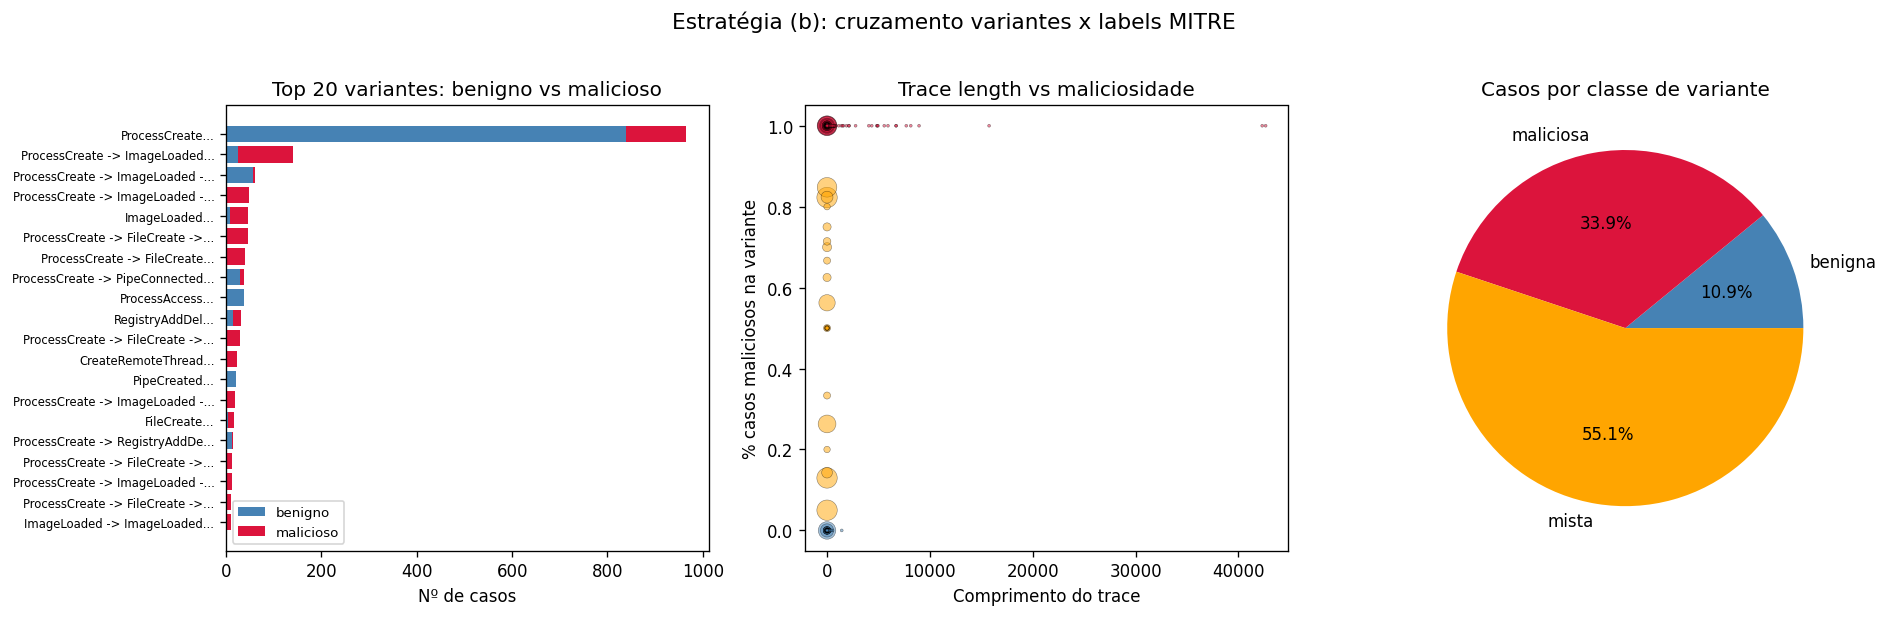

In [29]:
# === VISUALIZAÇÃO: distribuição de variantes por classe ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. barras empilhadas: top 20 variantes por composição benigno/malicioso
top20 = variant_profile.head(20).copy()
top20["label"] = top20["trace_str"].str[:30] + "..."
ax = axes[0]
ax.barh(range(len(top20)), top20["n_benign"], label="benigno", color="steelblue")
ax.barh(range(len(top20)), top20["n_malicious"], left=top20["n_benign"], label="malicioso", color="crimson")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["label"], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Nº de casos")
ax.set_title("Top 20 variantes: benigno vs malicioso")
ax.legend(fontsize=8)

# 2. scatter: tamanho do trace vs % malicioso (cada ponto = uma variante)
ax = axes[1]
colors = variant_profile["class"].map({"benigna": "steelblue", "mista": "orange", "maliciosa": "crimson"})
ax.scatter(
    variant_profile["trace_len"],
    variant_profile["pct_malicious"],
    c=colors, s=variant_profile["n_cases"].clip(upper=50) * 3,
    alpha=0.5, edgecolors="k", linewidths=0.3
)
ax.set_xlabel("Comprimento do trace")
ax.set_ylabel("% casos maliciosos na variante")
ax.set_title("Trace length vs maliciosidade")

# 3. pizza: distribuição de casos por classe de variante
ax = axes[2]
class_counts = variant_profile.groupby("class")["n_cases"].sum()
ax.pie(
    class_counts,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=["steelblue", "crimson", "orange"],
)
ax.set_title("Casos por classe de variante")

plt.suptitle("Estratégia (b): cruzamento variantes x labels MITRE", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("Comiset23_Lab_Dataset/strategy_b_variants_vs_labels.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# === VARIANTES MISTAS: onde benigno e malicioso coexistem ===
mixed = variant_profile[variant_profile["class"] == "mista"].sort_values("n_cases", ascending=False)
print(f"Variantes mistas (têm casos benignos E maliciosos): {len(mixed)}\n")
for _, row in mixed.iterrows():
    trace_display = row["trace_str"]
    if len(trace_display) > 80:
        trace_display = trace_display[:77] + "..."
    print(
        f"  {row['n_malicious']}/{row['n_cases']} maliciosos"
        f"  |  proc={row['example_process']}"
        f"  |  {trace_display}"
    )

Variantes mistas (têm casos benignos E maliciosos): 23

  125/964 maliciosos  |  proc=gpupdate.exe  |  ProcessCreate
  116/141 maliciosos  |  proc=schtasks.exe  |  ProcessCreate -> ImageLoaded
  3/60 maliciosos  |  proc=backgroundtaskhost.exe  |  ProcessCreate -> ImageLoaded -> RegistryAddDel
  39/46 maliciosos  |  proc=installassistservice.exe  |  ImageLoaded
  10/38 maliciosos  |  proc=wsqmcons.exe  |  ProcessCreate -> PipeConnected
  18/32 maliciosos  |  proc=firefox.exe  |  RegistryAddDel
  14/17 maliciosos  |  proc=msdtc.exe  |  FileCreate
  2/14 maliciosos  |  proc=backgroundtaskhost.exe  |  ProcessCreate -> RegistryAddDel -> ImageLoaded
  7/10 maliciosos  |  proc=cmd.exe  |  ProcessCreate -> FileDelete
  6/8 maliciosos  |  proc=wsandroidapphelper.exe  |  ProcessCreate -> ImageLoaded -> ImageLoaded
  5/8 maliciosos  |  proc=msascui.exe  |  ProcessCreate -> RegistryAddDel
  5/7 maliciosos  |  proc=vssvc.exe  |  RegistryAddDel -> RegistryAddDel
  4/6 maliciosos  |  proc=vmtoolsd.ex

---

# Pareto

> Antes de discutir Pareto precisamos ajustar a questão das variantes. 

> O primeiro passo seria identificar onde os traces anômalos estão no plot que você apresentou.

In [41]:
# cumulativo em porcentagem
cumsum = variant_counts.cumsum() / variant_counts.sum()

# achar quantas variantes cobrem o threshold
n_pareto = (cumsum <= PARETO_THRESHOLD).sum() + 1
pct_variants = n_pareto / n_variants

print(f"Pareto ({PARETO_THRESHOLD:.0%} dos casos):")
print(f"  {n_pareto:,} variantes de {n_variants:,} ({pct_variants:.2%})")

n = 10
print(f"\nTop {n} variantes:")
for i, (trace, count) in enumerate(variant_counts.head(n).items()):
    pct = count / n_cases
    activities = " -> ".join(trace)
    # truncar se muito longo
    if len(activities) > 80:
        activities = activities[:77] + "..."
    print(f"  {i+1:>3}. [{count:>6,} casos, {pct:>5.1%}] {activities}")

Pareto (80% dos casos):
  170 variantes de 673 (25.26%)

Top 10 variantes:
    1. [   964 casos, 38.3%] ProcessCreate
    2. [   141 casos,  5.6%] ProcessCreate -> ImageLoaded
    3. [    60 casos,  2.4%] ProcessCreate -> ImageLoaded -> RegistryAddDel
    4. [    47 casos,  1.9%] ProcessCreate -> ImageLoaded -> RegistryAddDel -> PipeConnected
    5. [    46 casos,  1.8%] ImageLoaded
    6. [    45 casos,  1.8%] ProcessCreate -> FileCreate -> FileDelete
    7. [    40 casos,  1.6%] ProcessCreate -> FileCreate
    8. [    38 casos,  1.5%] ProcessCreate -> PipeConnected
    9. [    37 casos,  1.5%] ProcessAccess
   10. [    32 casos,  1.3%] RegistryAddDel


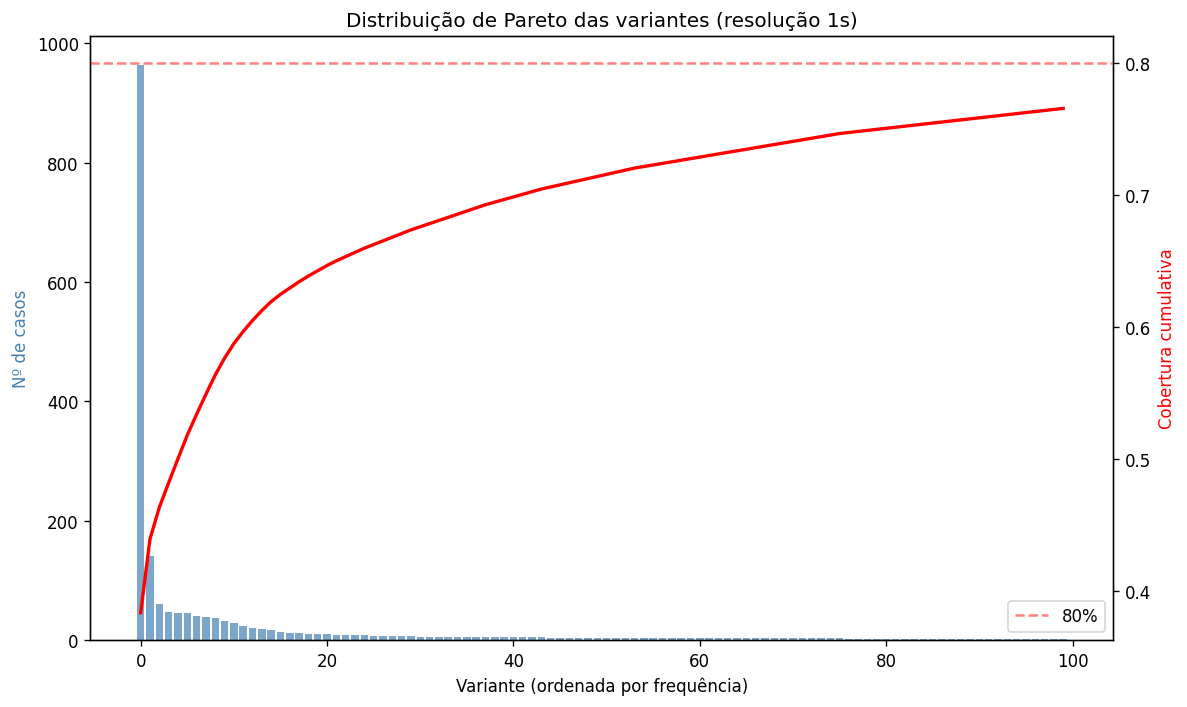

In [49]:
fig, ax1 = plt.subplots()

x = range(min(100, n_variants))  # mostrar até 100 variantes
ax1.bar(x, variant_counts.values[:len(x)], color="steelblue", alpha=0.7)
ax1.set_xlabel("Variante (ordenada por frequência)")
ax1.set_ylabel("Nº de casos", color="steelblue")
ax1.set_title(f"Distribuição de Pareto das variantes (resolução {TIME_RESOLUTION})")

ax2 = ax1.twinx()
ax2.plot(x, cumsum.values[:len(x)], color="red", linewidth=2)
ax2.axhline(y=PARETO_THRESHOLD, color="red", linestyle="--", alpha=0.5, label=f"{PARETO_THRESHOLD:.0%}")
ax2.set_ylabel("Cobertura cumulativa", color="red")
ax2.legend()

plt.tight_layout()
plt.savefig("Comiset23_Lab_Dataset/strategy_b_pareto.png", dpi=150)
plt.show()

---

# Salvando o dedup e `variant_df`

In [51]:
lab_b_dedup.to_parquet(
    f"Comiset23_Lab_Dataset/lab_b_dedup_{TIME_RESOLUTION}.parquet",
    index=False
)

# salvar variantes como referência
variant_df = variant_counts.reset_index()
variant_df.columns = ["trace", "count"]
variant_df["pct"] = variant_df["count"] / variant_df["count"].sum()
variant_df["cumsum"] = variant_df["pct"].cumsum()
variant_df.to_parquet(
    f"Comiset23_Lab_Dataset/lab_b_variants_{TIME_RESOLUTION}.parquet",
    index=False
)

print(f"Artefatos salvos com resolução {TIME_RESOLUTION}")

Artefatos salvos com resolução 1s


In [52]:
variant_df.sort_values("cumsum")

,trace,count,pct,cumsum
0,"(ProcessCreate,)",964,0.3831,0.3831
1,"(ProcessCreate, ImageLoaded)",141,0.0560,0.4392
2,"(ProcessCreate, ImageLoaded, RegistryAddDel)",60,0.0238,0.4630
3,"(ProcessCreate, ImageLoaded, RegistryAddDel, PipeConnected)",47,0.0187,0.4817
4,"(ImageLoaded,)",46,0.0183,0.5000
...,...,...,...,...
668,"(ProcessCreate, ImageLoaded, RegistryAddDel, PipeConnected, PipeConnected, PipeConnected, PipeConnected, PipeConnected, PipeConnected)",1,0.0004,0.9984
669,"(ProcessAccess, ProcessAccess, ProcessAccess, CreateRemoteThread, CreateRemoteThread, ProcessAccess, ProcessAccess, CreateRemoteThread, ProcessAccess, CreateRemoteThread)",1,0.0004,0.9988
670,"(ImageLoaded, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, RegistryAddDel, ...)",1,0.0004,0.9992
671,"(ImageLoaded, RegistryValueSet, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, RegistryAddDel, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ProcessAccess, ...)",1,0.0004,0.9996


# Sequência